In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

path = r"C:\Users\GAMING 3\Desktop\py\Dataset.csv"
df = pd.read_csv(path)

print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

Task1: Restaurant Ratings


Analyze the distribution of aggregate
ratings and determine the most common
rating range

In [3]:

agg_rating_distribution = df['Aggregate rating'].value_counts()
print(agg_rating_distribution)

Aggregate rating
0.0    2148
3.2     522
3.1     519
3.4     498
3.3     483
3.5     480
3.0     468
3.6     458
3.7     427
3.8     400
2.9     381
3.9     335
2.8     315
4.1     274
4.0     266
2.7     250
4.2     221
2.6     191
4.3     174
4.4     144
2.5     110
4.5      95
2.4      87
4.6      78
4.9      61
2.3      47
4.7      42
2.2      27
4.8      25
2.1      15
2.0       7
1.9       2
1.8       1
Name: count, dtype: int64


In [4]:
a = agg_rating_distribution.idxmax()
print("most common rating range is : ",a)

most common rating range is :  0.0


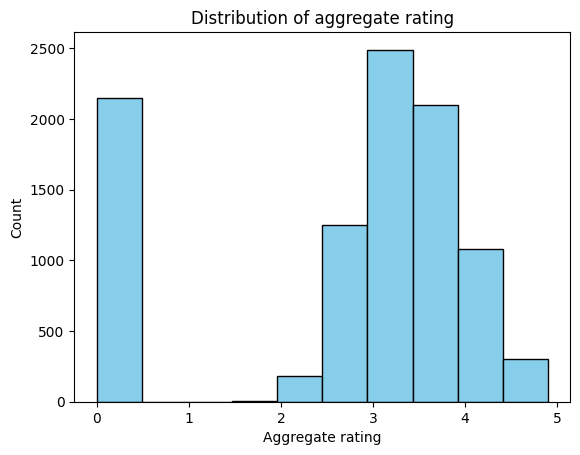

In [ ]:
plt.hist(df['Aggregate rating'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Aggregate rating')
plt.ylabel('Count')
plt.title('Distribution of aggregate rating')
plt.show()

Calculate the average number of votes
received by restaurants.

In [10]:
avg_vote = round(df['Votes'].mean(), 3)
print("The average number of votes received by restaurants :", avg_vote)


The average number of votes received by restaurants : 156.91


Task2: Cuisine Combination


Identify the most common combinations of
cuisines in the dataset.

In [14]:
common_combinations = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)
top10 = common_combinations.head(10)
print("Top 10 most common combinations are : ",top10)

Top 10 most common combinations are :  Cuisines
American, Coffee and Tea    4.9
American, BBQ, Sandwich     4.9
Burger, Bar Food, Steak     4.9
Sunda, Indonesian           4.9
Mughlai, Lucknowi           4.9
European, German            4.9
European, Contemporary      4.9
European, Asian, Indian     4.9
Italian, Deli               4.9
American, Sandwich, Tea     4.9
Name: Aggregate rating, dtype: float64


Determine if certain cuisine combinations
tend to have higher ratings.

In [16]:
max_rating = common_combinations.iloc[0]
print("The max rating is : ",max_rating)

The max rating is :  4.9


In [17]:
max_rated_rest = df.loc[df['Aggregate rating'] == max_rating]
print("Restaueants having the maximum rating : ", max_rated_rest['Restaurant Name'])


Restaueants having the maximum rating :  3                                           Ooma
8       Spiral - Sofitel Philippine Plaza Manila
10                              Silantro Fil-Mex
39                                    Coco Bambu
48                            Braseiro da G??vea
                          ...                   
9484              Restaurant Mosaic @ The Orient
9514                            Ministry of Crab
9524                                Gaga Manjero
9538                                   Starbucks
9540                            Draft Gastro Pub
Name: Restaurant Name, Length: 61, dtype: object


Task3: Geographic Analysis


Plot the locations of restaurants on a
map using longitude and latitude
coordinates.

In [27]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from geodatasets import get_path
import folium
from folium.plugins import HeatMap

In [28]:
path = r"C:\Users\GAMING 3\Desktop\py\Dataset.csv"
df = pd.read_csv(path)

print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [ ]:
print(df.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', '@dropdown'],
      dtype='object')


In [32]:
print(df[["Longitude", "Latitude"]])


       Longitude   Latitude
0     121.027535  14.565443
1     121.014101  14.553708
2     121.056831  14.581404
3     121.056475  14.585318
4     121.057508  14.584450
...          ...        ...
9546   28.977392  41.022793
9547   29.041297  41.009847
9548   29.034640  41.055817
9549   29.036019  41.057979
9550   29.026016  40.984776

[9551 rows x 2 columns]


In [ ]:
import geopandas as gpd
from shapely.geometry import Point
df["geometry"] = df.apply(lambda row: Point(row["Longitude"], row["Latitude"]), axis=1)
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
print(gdf.head())


   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

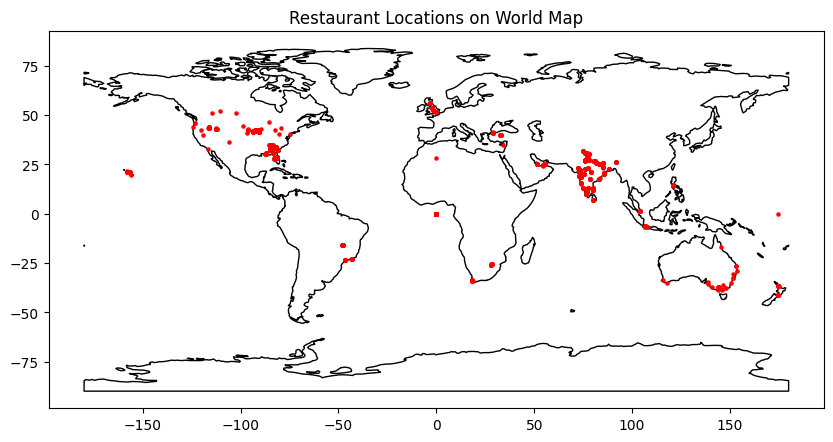

In [ ]:
world = geopandas.read_file(get_path("naturalearth.land"))
fig, ax = plt.subplots(figsize=(10, 8))
world.plot(ax=ax, color='white', edgecolor='black')
gdf.plot(ax=ax, marker='o', color='red', markersize=5)
plt.title("Restaurant Locations on World Map")
plt.show()


Identify any patterns or clusters of
restaurants in specific areas.

In [46]:
center_lat = df['Latitude'].mean()
center_lon = df['Longitude'].mean()
world_map = folium.Map(location=[center_lat, center_lon], zoom_start=2)
heat_data = df[['Latitude', 'Longitude']].values.tolist()
HeatMap(heat_data, radius=10).add_to(world_map)
world_map


Task4: Restaurant Chains


Identify if there are any restaurant chains
present in the dataset.

In [49]:
restaurant_chains = df.groupby('Restaurant Name').size().reset_index(name="outletCount")
new = restaurant_chains[restaurant_chains["outletCount"] > 1]
restaurant_chains = new.sort_values(by = "outletCount", ascending=False)
print(restaurant_chains[['Restaurant Name' ,"outletCount"]].head(10))

       Restaurant Name  outletCount
1112   Cafe Coffee Day           83
2100    Domino's Pizza           79
6107            Subway           63
2716  Green Chick Chop           51
4077        McDonald's           48
3478         Keventers           34
4964         Pizza Hut           30
2619             Giani           29
680     Baskin Robbins           28
663    Barbeque Nation           26


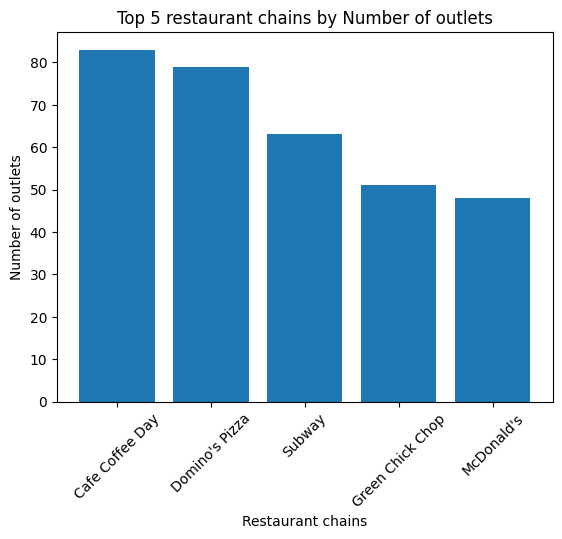

In [62]:
plt.bar(restaurant_chains["Restaurant Name"][:5], restaurant_chains["outletCount"][:5])
plt.xlabel('Restaurant chains')
plt.ylabel('Number of outlets')
plt.title("Top 5 restaurant chains by Number of outlets")
plt.xticks(rotation=45)
plt.show()

Analyze the ratings and popularity of
different restaurant chains.

In [55]:
ratings = df.groupby("Restaurant Name")["Aggregate rating"].mean().reset_index(name="Average Rating").sort_values(by="Average Rating",ascending=True)
print(ratings)

                               Restaurant Name  Average Rating
2400                                 Food Care             0.0
7394                       Zaika Tiffin Center             0.0
7395                          Zaika of Dilli 6             0.0
7396                     Zaika-E-Chaap Express             0.0
7345                                      Yeoh             0.0
...                                        ...             ...
6979             Tresind - Nassima Royal Hotel             4.9
6046  Spiral - Sofitel Philippine Plaza Manila             4.9
651                                        Bao             4.9
2135                             Duck & Waffle             4.9
7422             Zolocrust - Hotel Clarks Amer             4.9

[7446 rows x 2 columns]


In [59]:
votes = (df.groupby("Restaurant Name")["Votes"]
        .sum()
        .reset_index()
        .rename(columns={"Votes": "Total votes"})
        .sort_values(by="Total votes", ascending=True))
print(votes)


                Restaurant Name  Total votes
3541                KitchenYard            0
3543       Kith N Kin Cafeteria            0
7345                       Yeoh            0
7308                 Wow Noodle            0
7321               Xpert Bakers            0
...                         ...          ...
2297                 Farzi Cafe        10098
785                   Big Chill        10853
6944                       Toit        10934
102   AB's - Absolute Barbecues        13400
663             Barbeque Nation        28142

[7446 rows x 2 columns]


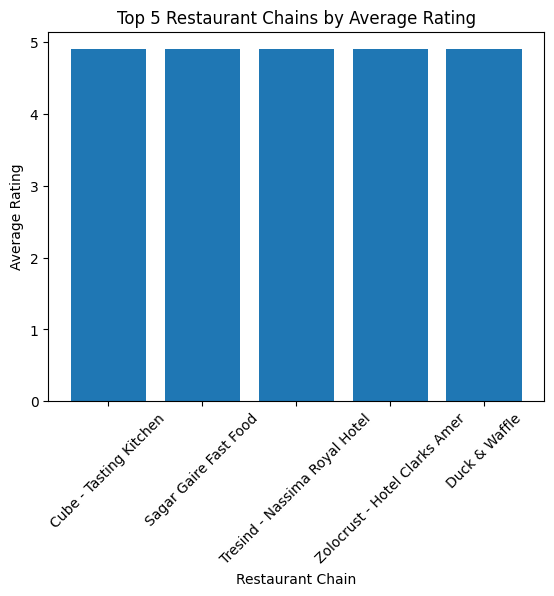

In [61]:
top5 = ratings.sort_values(by="Average Rating", ascending=False).head(5)
plt.bar(top5["Restaurant Name"], top5["Average Rating"])
plt.xlabel("Restaurant Chain")
plt.ylabel("Average Rating")
plt.title("Top 5 Restaurant Chains by Average Rating")
plt.xticks(rotation=45)
plt.show()


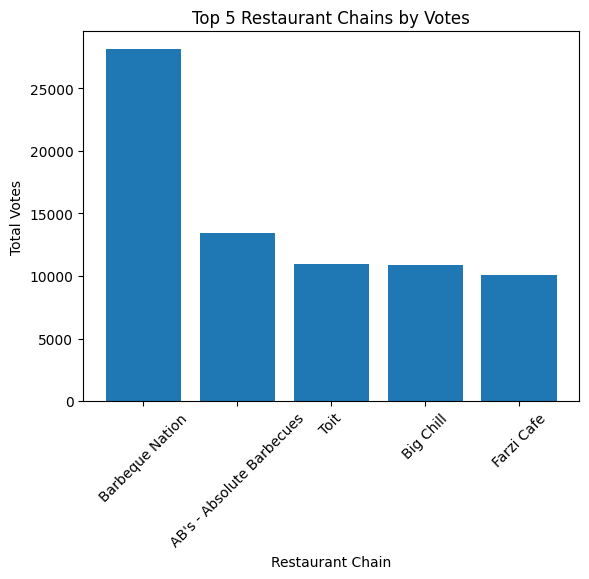

In [64]:

top5_votes = votes.sort_values(by="Total votes", ascending=False).head(5)
plt.bar(top5_votes["Restaurant Name"], top5_votes["Total votes"])
plt.xlabel("Restaurant Chain")
plt.ylabel("Total Votes")
plt.title("Top 5 Restaurant Chains by Votes")
plt.xticks(rotation=45)
plt.show()
